In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importing the dataset 
df=pd.read_csv(r"C:\Users\CHARLES\Desktop\New folder\realtor-data.zip.csv")

In [3]:
# viewing the top five rows of the dataset 
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [4]:
# having the summary of the dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


In [5]:
#viewing the rows and colunms in the dataset 
df.shape

(2226382, 12)

In [6]:
null_perc=df.isnull().sum()/df.shape[0]*100

In [7]:
df.isnull().sum()/df.shape[0]*100

brokered_by        0.203604
status             0.000000
price              0.069215
bed               21.618797
bath              22.986666
acre_lot          14.624130
street             0.488056
city               0.063197
state              0.000359
zip_code           0.013430
house_size        25.533983
prev_sold_date    32.981627
dtype: float64

In [8]:
null_perc_sorted = null_perc.sort_values()

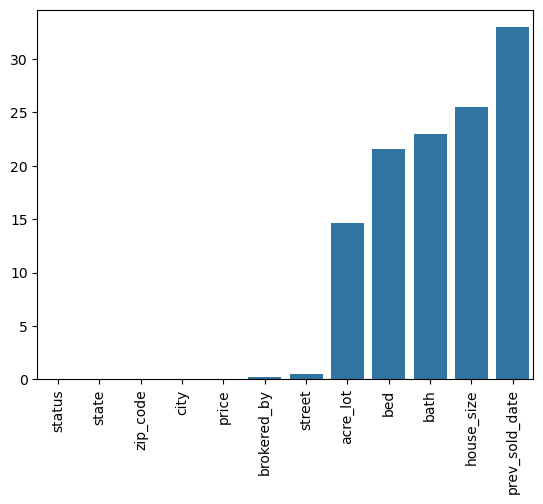

In [9]:
sns.barplot(data=null_perc_sorted)
plt.xticks(rotation=90)
plt.show()

In [20]:
#Mode manipulation to handle missing values 
df['bed'].fillna(df['bed'].mode()[0],inplace=True)
df['bath'].fillna(df['bath'].mode()[0],inplace=True)
df['acre_lot'].fillna(df['acre_lot'].mode()[0],inplace=True)
df['house_size'].fillna(df['house_size'].mode()[0],inplace=True)
df['price'].fillna(df['price'].mode()[0],inplace=True)


C:\Users\CHARLES\AppData\Local\Temp\ipykernel_3076\2438310678.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bed'].fillna(df['bed'].mode()[0],inplace=True)
C:\Users\CHARLES\AppData\Local\Temp\ipykernel_3076\2438310678.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [10]:
df = df.drop(['brokered_by', 'street','prev_sold_date','zip_code','city'], axis=1)

In [11]:
df.columns

Index(['status', 'price', 'bed', 'bath', 'acre_lot', 'state', 'house_size'], dtype='object')

In [12]:
df.duplicated().sum()

149214

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

0

In [16]:
df.isnull().sum()/df.shape[0]*100

status        0.000000
price         0.063307
bed           0.000000
bath          0.000000
acre_lot      0.000000
state         0.000385
house_size    0.000000
dtype: float64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2077168 entries, 0 to 2226381
Data columns (total 7 columns):
 #   Column      Dtype  
---  ------      -----  
 0   status      object 
 1   price       float64
 2   bed         float64
 3   bath        float64
 4   acre_lot    float64
 5   state       object 
 6   house_size  float64
dtypes: float64(5), object(2)
memory usage: 126.8+ MB


In [22]:
df.isnull().sum()

status        0
price         0
bed           0
bath          0
acre_lot      0
state         8
house_size    0
dtype: int64

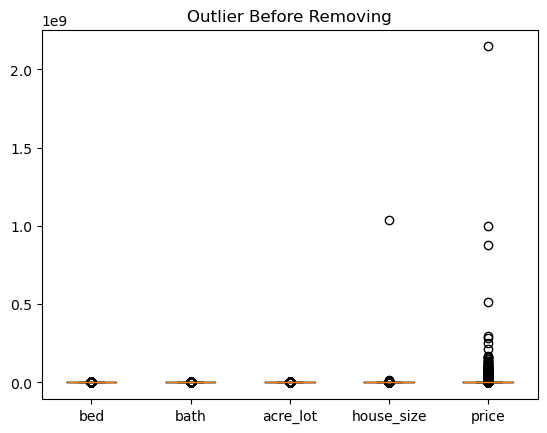

In [24]:
numerical_columns=['bed','bath','acre_lot','house_size','price']
plt.boxplot(df[numerical_columns])
plt.xticks([1,2,3,4,5],numerical_columns)
plt.title('Outlier Before Removing')
plt.show()

In [27]:
Q1=df[numerical_columns].quantile(0.25)
Q3=df[numerical_columns].quantile(0.75)
IQR=Q3-Q1
df=df[~((df[numerical_columns]<(Q1-1.5*IQR))| (df[numerical_columns]>(Q3+1.5*IQR))).any(axis=1)]

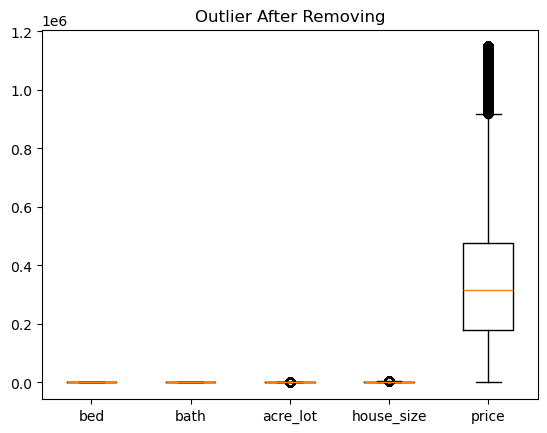

In [29]:
numerical_columns=['bed','bath','acre_lot','house_size','price']
plt.boxplot(df[numerical_columns])
plt.xticks([1,2,3,4,5],numerical_columns)
plt.title('Outlier After Removing')
plt.show()

In [32]:
# Exploratory Data Analysis
df_corr=df.corr(numeric_only=True)

<Axes: >

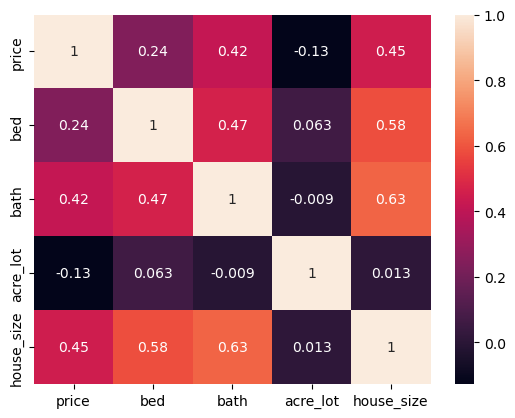

In [36]:
sns.heatmap(data=df_corr,annot=True)

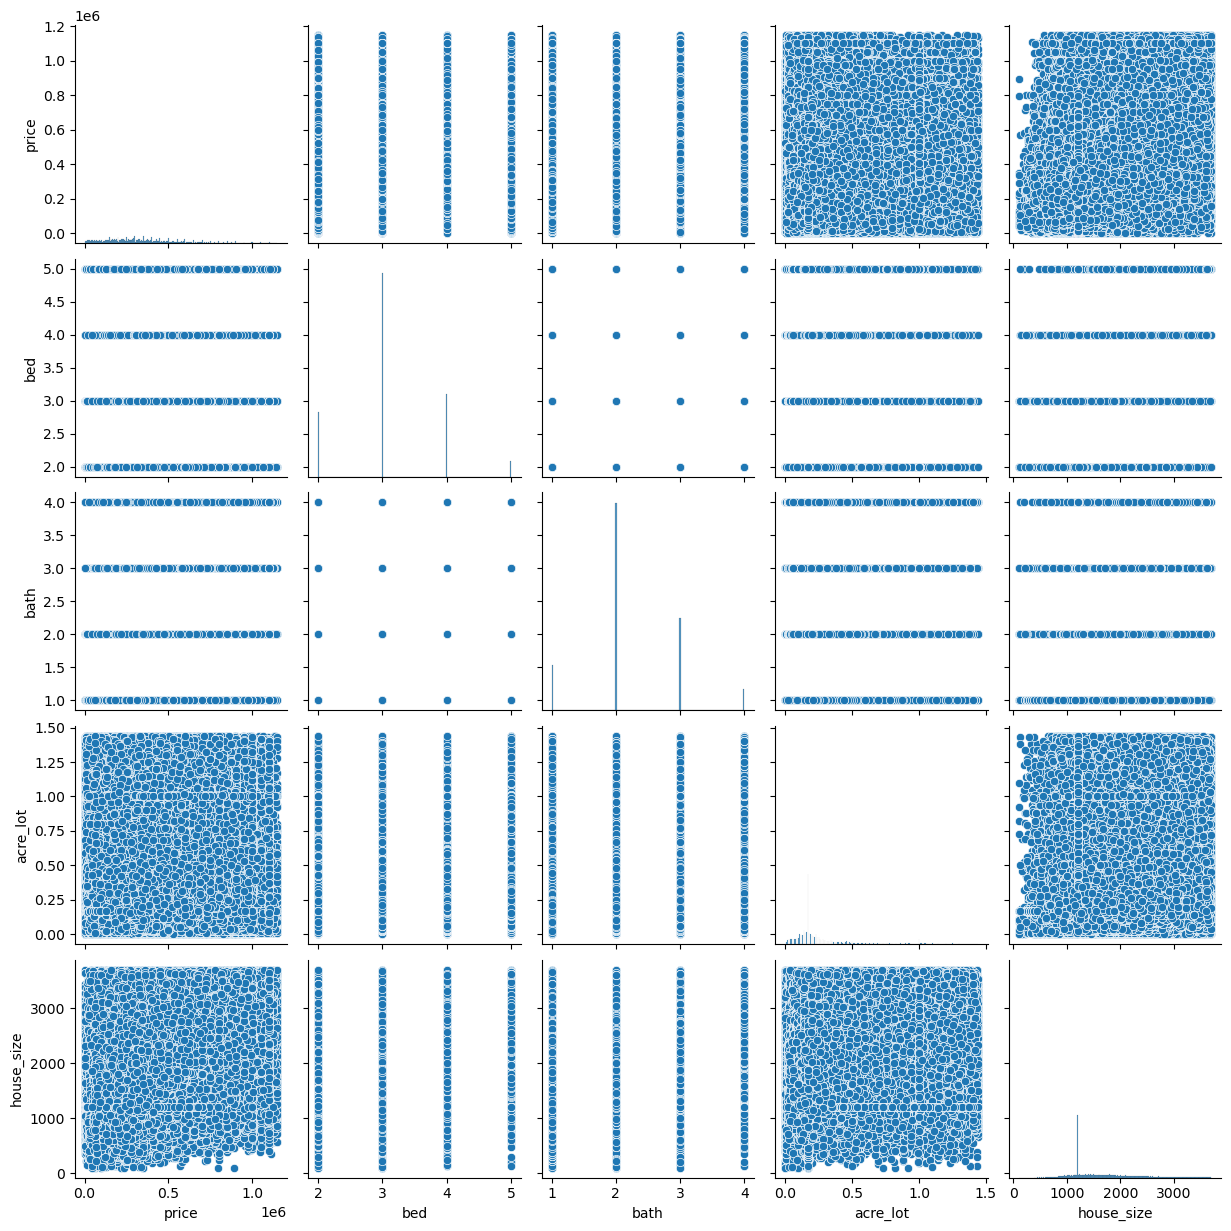

In [37]:
sns.pairplot(df)